In [12]:
import pandas as pd

In [13]:
df = pd.read_csv('Survivor_Support_Dataset.csv')
df.head()

,case_id,district,currently_safe,perpetrator_nearby,support_needed,safe_shelter,medical_care,counselling,police_assistance,legal_support,other_support,priority_level
0,C001,Lilongwe,No,Yes,Safe Shelter; Medical Care; Police Assistance,1,1,0,1,0,0,Urgent
1,C002,Dedza,No,Yes,Safe Shelter; Counselling; Police Assistance,1,0,1,1,0,0,Urgent
2,C003,Dowa,No,Yes,Safe Shelter; Medical Care; Counselling; Polic...,1,1,1,1,0,0,Urgent
3,C004,Mchinji,No,Yes,Safe Shelter; Police Assistance; Legal Support,1,0,0,1,1,0,Urgent
4,C005,Kasungu,No,Unsure,Safe Shelter; Medical Care; Police Assistance,1,1,0,1,0,0,Urgent


In [14]:
df.shape

(50, 12)

In [15]:
df.columns #columns we have in the dataset

Index(['case_id', 'district', 'currently_safe', 'perpetrator_nearby',
       'support_needed', 'safe_shelter', 'medical_care', 'counselling',
       'police_assistance', 'legal_support', 'other_support',
       'priority_level'],
      dtype='str')

In [16]:
df["priority_level"].value_counts() 
#checking the distribution of the priority level column 
# priority_level column is the target variable 

priority_level
Urgent      17
High        17
Standard    16
Name: count, dtype: int64

In [17]:
#now ploting our x and y variables to separate the features and the target variable

x = df[
    [
        "currently_safe",
        "perpetrator_nearby",
        "safe_shelter",
        "medical_care",
        "counselling",
        "police_assistance",
        "legal_support",
        "other_support"
    ]
]

y = df["priority_level"]

In [18]:
x.head() #checking the features

,currently_safe,perpetrator_nearby,safe_shelter,medical_care,counselling,police_assistance,legal_support,other_support
0,No,Yes,1,1,0,1,0,0
1,No,Yes,1,0,1,1,0,0
2,No,Yes,1,1,1,1,0,0
3,No,Yes,1,0,0,1,1,0
4,No,Unsure,1,1,0,1,0,0


In [19]:
y.head() #checking the target variable

0    Urgent
1    Urgent
2    Urgent
3    Urgent
4    Urgent
Name: priority_level, dtype: str

In [20]:
x.dtypes

currently_safe          str
perpetrator_nearby      str
safe_shelter          int64
medical_care          int64
counselling           int64
police_assistance     int64
legal_support         int64
other_support         int64
dtype: object

In [23]:
#now we need to cheng the 2 variables that are string into numerical values 
x["currently_safe"] = x["currently_safe"].map({
    "Yes": 1,
    "No": 0
})



In [25]:
x["perpetrator_nearby"] = x["perpetrator_nearby"].map({
    "Yes": 1,
    "No": 0,
    "Unsure": 0.5
})

In [26]:
x.head() #checking the features to see if the changes have been made successfully

,currently_safe,perpetrator_nearby,safe_shelter,medical_care,counselling,police_assistance,legal_support,other_support
0,0,1.0,1,1,0,1,0,0
1,0,1.0,1,0,1,1,0,0
2,0,1.0,1,1,1,1,0,0
3,0,1.0,1,0,0,1,1,0
4,0,0.5,1,1,0,1,0,0


In [31]:
# now will split the data into training and testing data
from sklearn.model_selection import train_test_split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
#now to chech the training and testing data
print("Training cases:", len(X_train))
print("Testing cases:", len(X_test))

Training cases: 40
Testing cases: 10


In [ ]:
#checking the distribution of the target variable in the training and testing data
print(y_train.value_counts())
print(y_test.value_counts())

priority_level
Urgent      14
High        13
Standard    13
Name: count, dtype: int64
priority_level
High        4
Standard    3
Urgent      3
Name: count, dtype: int64


In [35]:
#our model will use a decision tree classifier to predict the priority level of survivors based on the features provided.
from sklearn.tree import DecisionTreeClassifier

In [36]:
model = DecisionTreeClassifier(
    random_state=42
)

In [37]:
#now to train the model using the training data
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [38]:
# now to make predictions using the testing data
y_pred = model.predict(X_test)

In [ ]:
print("Predictions:", y_pred) #we can see the predictions made by the model for the testing data

Predictions: ['Standard' 'High' 'Urgent' 'High' 'Standard' 'Urgent' 'Urgent' 'Standard'
 'High' 'Standard']


In [40]:
#now we will compare the predictions made by the model with the actual values in the testing data to see how well the model performed
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,Standard,Standard
1,High,High
2,Urgent,Urgent
3,High,High
4,High,Standard
5,Urgent,Urgent
6,Urgent,Urgent
7,Standard,Standard
8,High,High
9,Standard,Standard


In [41]:
#cheking the model's accuracy
from sklearn.metrics import accuracy_score

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9


In [43]:
# now for the rest of the metrics to evaluate the model's performance, we will use precision, recall, and F1-score.
from sklearn.metrics import classification_report

In [44]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.75      0.86         4
    Standard       0.75      1.00      0.86         3
      Urgent       1.00      1.00      1.00         3

    accuracy                           0.90        10
   macro avg       0.92      0.92      0.90        10
weighted avg       0.93      0.90      0.90        10



In [46]:
# visualization of the decision tree model to understand how it makes 
from sklearn.tree import plot_tree


In [47]:

import matplotlib.pyplot as plt

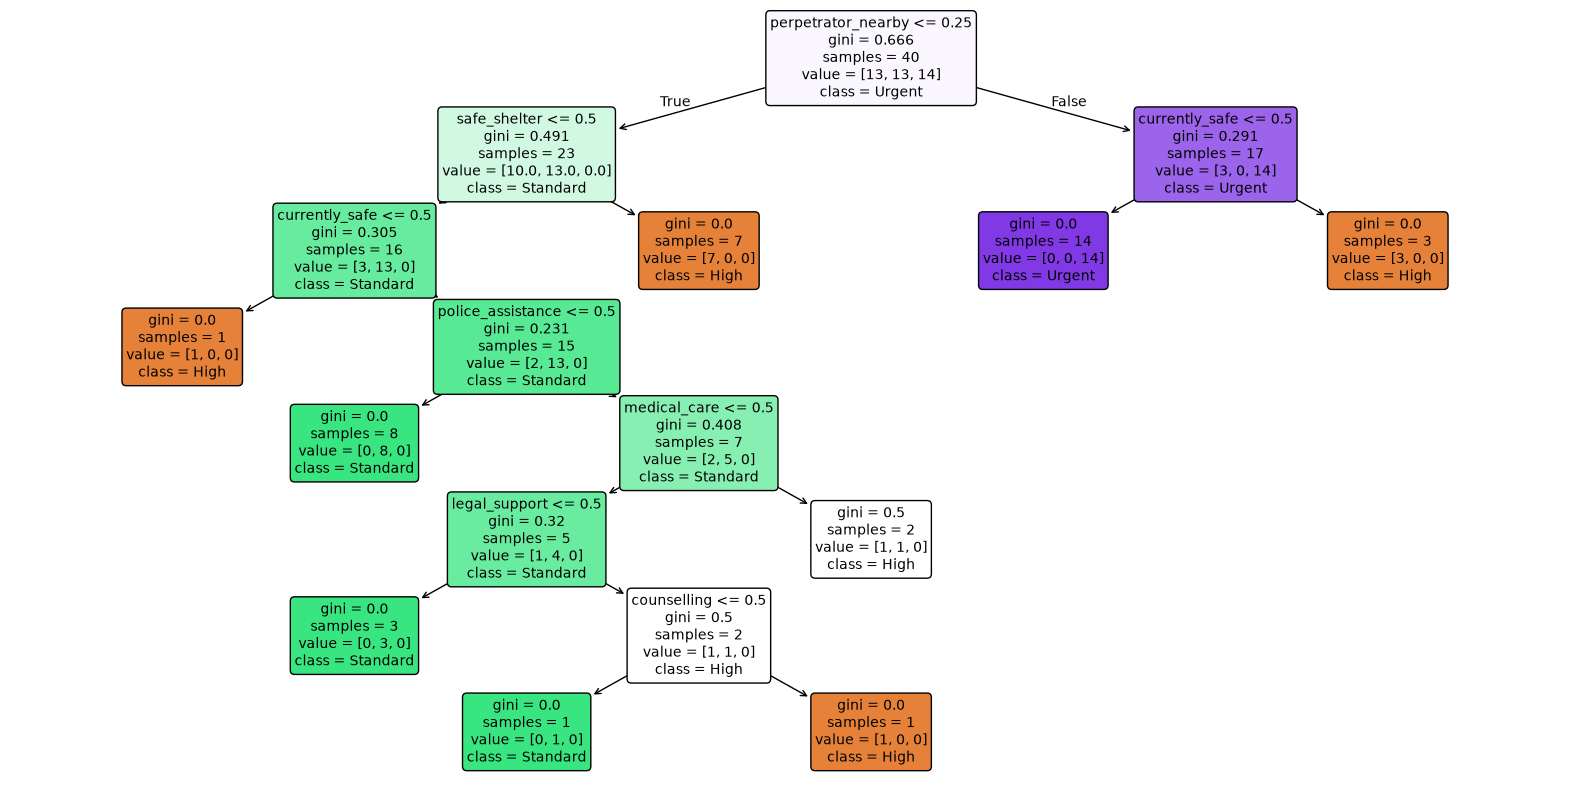

In [48]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [49]:
# now that we have evaluated the model, now we will test eith a new sample data to see how the model performs on unseen data.
new_case = pd.DataFrame({
    "currently_safe": [0],
    "perpetrator_nearby": [1],
    "safe_shelter": [1],
    "medical_care": [0],
    "counselling": [1],
    "police_assistance": [1],
    "legal_support": [0],
    "other_support": [0]
})

prediction = model.predict(new_case)

print("Predicted priority:", prediction[0])

Predicted priority: Urgent


In [ ]:
#looking at the probabilities of each class for the new case, we can see how confident the model is in its prediction.
probabilities = model.predict_proba(new_case)

print(probabilities)
print(model.classes_)

[[0. 0. 1.]]
['High' 'Standard' 'Urgent']


In [51]:
# since the model is ready, we want to add a function for the recommended services needed. this will be based on what support the survivor has selected 
def recommend_services(case, priority):
    
    recommendations = []

    # Safety-related recommendations (for urgent cases)
    if priority == "Urgent":
        recommendations.append("Immediate safety assessment")
    
    # Support requested by the survivor
    if case["safe_shelter"] == 1:
        recommendations.append("Safe Shelter")
    
    if case["medical_care"] == 1:
        recommendations.append("Medical Care")
    
    if case["counselling"] == 1:
        recommendations.append("Counselling / Psychosocial Support")
    
    if case["police_assistance"] == 1:
        recommendations.append("Police / Victim Support Unit")
    
    if case["legal_support"] == 1:
        recommendations.append("Legal Support")
    
    if case["other_support"] == 1:
        recommendations.append("Other Support Services")

    return recommendations

In [52]:
# using the new case we entred above 

priority = prediction[0]

recommendations = recommend_services(
    new_case.iloc[0],
    priority
)

print("Priority:", priority)
print("Recommended services:")

for service in recommendations:
    print("-", service)

Priority: Urgent
Recommended services:
- Immediate safety assessment
- Safe Shelter
- Counselling / Psychosocial Support
- Police / Victim Support Unit


In [53]:
# to save the decision tree model for future use, without having to retrain it. 
import joblib

In [54]:
joblib.dump(model, "gbv_priority_model.pkl")

['gbv_priority_model.pkl']

In [56]:
# now saving the features in order. 
joblib.dump(x.columns.tolist(), "model_features.pkl")

['model_features.pkl']